# Cutouts and Capacity Factors (2016-2025)

This notebook creates ERA5 cutouts (.nc) for 2016-2025 and computes wind/solar capacity factors using the same workflow as `config.py` and `case_analysis.ipynb`.

Important:
- Set `GENERATE_CUTOUTS = True` only when you want to create missing .nc files.
- Keep it `False` for analysis-only runs.

In [9]:
import importlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import config
config = importlib.reload(config)

# -------- User parameters --------
CASE_FOLDER = "input_new_zealand"
CASE_NAME = "new_zealand"
YEARS = [2025] #list(range(2016, 2026))

# Turn on only when you need to create/update .nc files
GENERATE_CUTOUTS = True
OVERWRITE_EXISTING_CUTOUTS = False

# VRE method and technology assumptions (same family as case_analysis.ipynb)
VRE_METHOD = "atlite_technology"
WIND_TURBINE = "Vestas_V112_3MW"
SOLAR_PANEL = "CSi"
SOLAR_ORIENTATION = "latitude_optimal"

# Preferred target grid for new consistent cutouts
DX = 0.25
DY = 0.25

# Grid locking mode:
# - "fixed_bounds": fixed geographic box (used here for full New Zealand)
# - "match_existing_year": force all years to match one existing cutout
# - "use_nodes_bounds": use nodes +/-1 deg with DX,DY above
GRID_LOCK_MODE = "fixed_bounds"
FIXED_BOUNDS = (165.5, 179.0, -48.0, -33.5)  # Full New Zealand (+ Stewart margin)
REFERENCE_YEAR_FOR_GRID = 2019

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"Case folder: {CASE_FOLDER}")
print(f"Case: {CASE_NAME}")
print(f"Years: {YEARS[0]}-{YEARS[-1]}")
print(f"Generate cutouts: {GENERATE_CUTOUTS}")
print(f"Overwrite existing cutouts: {OVERWRITE_EXISTING_CUTOUTS}")
print(f"Grid lock mode: {GRID_LOCK_MODE}")

Case folder: input_new_zealand
Case: new_zealand
Years: 2025-2025
Generate cutouts: True
Overwrite existing cutouts: False
Grid lock mode: fixed_bounds


In [10]:
import numpy as np
import xarray as xr

paths = config.get_case_paths(CASE_FOLDER)
nodes_df = config.load_nodes_from_csv(paths["csv_nodes"])
if nodes_df is None or nodes_df.empty:
    raise ValueError("Nodes CSV is empty or missing.")

if not {"lat", "lon"}.issubset(nodes_df.columns):
    raise ValueError("Nodes CSV must include lat and lon columns.")

valid_coords = nodes_df[["lat", "lon"]].dropna()
if valid_coords.empty:
    raise ValueError("No valid lat/lon coordinates found in nodes CSV.")

padding_deg = 1.0
lon_min = float(valid_coords["lon"].min()) - padding_deg
lon_max = float(valid_coords["lon"].max()) + padding_deg
lat_min = float(valid_coords["lat"].min()) - padding_deg
lat_max = float(valid_coords["lat"].max()) + padding_deg
derived_bounds = (lon_min, lon_max, lat_min, lat_max)

# Resolve canonical grid once, then reuse for all years.
if GRID_LOCK_MODE == "fixed_bounds":
    lock_bounds = tuple(float(v) for v in FIXED_BOUNDS)
    lock_dx = float(DX)
    lock_dy = float(DY)
elif GRID_LOCK_MODE == "match_existing_year":
    ref_path = DATA_DIR / f"{CASE_NAME}_{REFERENCE_YEAR_FOR_GRID}.nc"
    if not ref_path.exists():
        raise FileNotFoundError(
            f"Reference cutout not found for grid lock mode: {ref_path}"
        )
    with xr.open_dataset(ref_path) as ds_ref:
        x_vals = np.array(ds_ref["x"].values)
        y_vals = np.array(ds_ref["y"].values)
        lon_min_lock = float(np.min(x_vals))
        lon_max_lock = float(np.max(x_vals))
        lat_min_lock = float(np.min(y_vals))
        lat_max_lock = float(np.max(y_vals))
        dx_lock = float(np.median(np.diff(np.sort(np.unique(x_vals)))))
        dy_lock = float(np.median(np.diff(np.sort(np.unique(y_vals)))))

    lock_bounds = (lon_min_lock, lon_max_lock, lat_min_lock, lat_max_lock)
    lock_dx = dx_lock
    lock_dy = dy_lock
else:
    lock_bounds = derived_bounds
    lock_dx = float(DX)
    lock_dy = float(DY)

print("Nodes used for VRE profiles:")
display(nodes_df[["zone", "lat", "lon"]])

print("\nDerived bounds from nodes (+/-1 deg):")
print(f"lon_min={lon_min:.4f}, lon_max={lon_max:.4f}, lat_min={lat_min:.4f}, lat_max={lat_max:.4f}")

print("\nCanonical grid to use for all generated years:")
print(f"bounds={lock_bounds}")
print(f"dx={lock_dx}, dy={lock_dy}")

Nodes used for VRE profiles:


,zone,lat,lon
0,auckland,-36.8485,174.7633
1,hamilton,-37.7870,175.2793
2,wellington,-41.2866,174.7756
3,christchurch,-43.5321,172.6362
4,dunedin,-45.8788,170.5028



Derived bounds from nodes (+/-1 deg):
lon_min=169.5028, lon_max=176.2793, lat_min=-46.8788, lat_max=-35.8485

Canonical grid to use for all generated years:
bounds=(165.5, 179.0, -48.0, -33.5)
dx=0.25, dy=0.25


In [11]:

# ── Connectivity & credentials diagnostic ─────────────────────────────────────
import subprocess, socket, urllib.request, json, os, time

print("=" * 60)
print("1. DNS resolution — cds.climate.copernicus.eu")
try:
    ip = socket.gethostbyname("cds.climate.copernicus.eu")
    print(f"   OK  → {ip}")
except Exception as e:
    print(f"   FAIL → {e}")

print()
print("2. HTTP GET — CDS API root (5 s timeout)")
try:
    t0 = time.time()
    with urllib.request.urlopen("https://cds.climate.copernicus.eu/api", timeout=5) as r:
        print(f"   OK  → HTTP {r.status}  ({time.time()-t0:.1f}s)")
except Exception as e:
    print(f"   FAIL → {e}")

print()
print("3. CDS API credentials (~/.cdsapirc)")
cdsapirc = os.path.expanduser("~/.cdsapirc")
if os.path.exists(cdsapirc):
    with open(cdsapirc) as f:
        lines = f.read().splitlines()
    for line in lines:
        if line.startswith("key"):
            # mask key value, show only first 6 chars
            parts = line.split(":", 1)
            val = parts[1].strip() if len(parts) > 1 else ""
            masked = val[:6] + "****" if len(val) > 6 else "****"
            print(f"   key: {masked}")
        else:
            print(f"   {line}")
else:
    print("   MISSING — create ~/.cdsapirc with url and key")

print()
print("4. Quick cdsapi ping (actual API call, 10 s timeout)")
try:
    import cdsapi
    c = cdsapi.Client(quiet=True, wait_until_complete=False, retry_max=1)
    print("   Client created OK")
except Exception as e:
    print(f"   FAIL → {e}")

print("=" * 60)


1. DNS resolution — cds.climate.copernicus.eu
   OK  → 136.156.139.54

2. HTTP GET — CDS API root (5 s timeout)
   OK  → HTTP 202  (1.0s)

3. CDS API credentials (~/.cdsapirc)
   url: https://cds.climate.copernicus.eu/api
   key: a730a8****

4. Quick cdsapi ping (actual API call, 10 s timeout)
   Client created OK


In [12]:
# Validation of generated cutouts (existence, size, readability, metadata)
import xarray as xr

years_check = [2016, 2017, 2018, 2019]
rows = []

for y in years_check:
    p = DATA_DIR / f"{CASE_NAME}_{y}.nc"
    rec = {
        "year": y,
        "exists": p.exists(),
        "size_MB": None,
        "open_ok": False,
        "time_len": None,
        "x_len": None,
        "y_len": None,
        "time_start": None,
        "time_end": None,
        "n_data_vars": None,
    }

    if p.exists():
        rec["size_MB"] = p.stat().st_size / (1024**2)
        try:
            with xr.open_dataset(p) as ds:
                rec["open_ok"] = True
                rec["time_len"] = int(ds.sizes.get("time", 0))
                rec["x_len"] = int(ds.sizes.get("x", 0))
                rec["y_len"] = int(ds.sizes.get("y", 0))
                rec["n_data_vars"] = int(len(ds.data_vars))
                if "time" in ds.coords and ds.sizes.get("time", 0) > 0:
                    rec["time_start"] = str(ds["time"].values[0])
                    rec["time_end"] = str(ds["time"].values[-1])
        except Exception as e:
            rec["open_ok"] = False
            rec["time_start"] = f"ERROR: {e}"

    rows.append(rec)

check_df = pd.DataFrame(rows)

print("Cutout validation (2016-2019):")
display(check_df)

ok_files = check_df[(check_df["exists"]) & (check_df["open_ok"])].copy()
if not ok_files.empty:
    min_mb = ok_files["size_MB"].min()
    max_mb = ok_files["size_MB"].max()
    ratio = (max_mb / min_mb) if min_mb and min_mb > 0 else None
    print(f"Size range among valid files: {min_mb:.2f} MB to {max_mb:.2f} MB")
    if ratio is not None:
        print(f"Max/min size ratio: {ratio:.3f}")

    same_grid = ok_files[["x_len", "y_len"]].nunique().max() == 1
    print(f"Same spatial grid across valid files: {same_grid}")

    same_time_len = ok_files["time_len"].nunique() == 1
    print(f"Same number of timesteps across valid files: {same_time_len}")
else:
    print("No valid files found to compare.")

Cutout validation (2016-2019):


,year,exists,size_MB,open_ok,time_len,x_len,y_len,time_start,time_end,n_data_vars
0,2016,False,None,False,None,None,None,None,None,None
1,2017,False,None,False,None,None,None,None,None,None
2,2018,False,None,False,None,None,None,None,None,None
3,2019,False,None,False,None,None,None,None,None,None


No valid files found to compare.


In [13]:
# Compare spatial extent/resolution across cutouts
import numpy as np

extent_rows = []
for y in YEARS:
    p = DATA_DIR / f"{CASE_NAME}_{y}.nc"
    if not p.exists():
        continue

    with xr.open_dataset(p) as ds:
        x_vals = np.array(ds["x"].values)
        y_vals = np.array(ds["y"].values)
        extent_rows.append({
            "year": y,
            "x_min": float(np.min(x_vals)),
            "x_max": float(np.max(x_vals)),
            "y_min": float(np.min(y_vals)),
            "y_max": float(np.max(y_vals)),
            "dx_inferred": float(np.median(np.diff(np.sort(np.unique(x_vals))))) if len(np.unique(x_vals)) > 1 else np.nan,
            "dy_inferred": float(np.median(np.diff(np.sort(np.unique(y_vals))))) if len(np.unique(y_vals)) > 1 else np.nan,
            "x_len": int(len(np.unique(x_vals))),
            "y_len": int(len(np.unique(y_vals))),
        })

extent_df = pd.DataFrame(extent_rows)
print("Spatial extent/resolution by year:")

if extent_df.empty:
    print("No cutout files found yet. Run the generation cell first or set GENERATE_CUTOUTS = True.")
else:
    extent_df = extent_df.sort_values("year")
    display(extent_df)

    reference = extent_df.iloc[0]
    same_extent = (
        (extent_df["x_min"] == reference["x_min"]).all()
        and (extent_df["x_max"] == reference["x_max"]).all()
        and (extent_df["y_min"] == reference["y_min"]).all()
        and (extent_df["y_max"] == reference["y_max"]).all()
    )
    same_resolution = (
        np.isclose(extent_df["dx_inferred"], reference["dx_inferred"]).all()
        and np.isclose(extent_df["dy_inferred"], reference["dy_inferred"]).all()
    )
    print(f"All years have same extent: {same_extent}")
    print(f"All years have same resolution: {same_resolution}")

Spatial extent/resolution by year:
No cutout files found yet. Run the generation cell first or set GENERATE_CUTOUTS = True.


In [14]:
existing = []
created = []
missing = []

for year in YEARS:
    cutout_file = DATA_DIR / f"{CASE_NAME}_{year}.nc"
    exists_before = cutout_file.exists()

    if GENERATE_CUTOUTS:
        force_prepare = OVERWRITE_EXISTING_CUTOUTS or (not exists_before)
        _ = config.get_case_cutout(
            year=year,
            force_prepare=force_prepare,
            base_dir="data",
            case_name=CASE_NAME,
            bounds=lock_bounds,
            nodes_df=nodes_df,
            dx=lock_dx,
            dy=lock_dy,
        )

    if cutout_file.exists():
        if exists_before:
            existing.append(year)
        else:
            created.append(year)
    else:
        missing.append(year)

print(f"Existing cutouts: {existing}")
print(f"Created now: {created}")
print(f"Missing cutouts: {missing}")

if missing and not GENERATE_CUTOUTS:
    print("\nSome cutouts are missing. Set GENERATE_CUTOUTS = True and run this cell once.")

de55363caa580b0e3b561b814f4327be.grib:   0%|          | 0.00/303M [00:00<?, ?B/s]

9011ecd2cb9584cd038c0d301cdc9215.grib:   0%|          | 0.00/9.61k [00:00<?, ?B/s]

d1984f22e822193257d347153f038a92.grib:   0%|          | 0.00/165M [00:00<?, ?B/s]

186dd4d281eb5f621cbd1337d266d974.grib:   0%|          | 0.00/55.1M [00:00<?, ?B/s]

654e31217e5cd2a1264ef12d1be8228a.grib:   0%|          | 0.00/220M [00:00<?, ?B/s]

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\data.py:250: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = cutout.data.merge(ds[missing_vars.values]).assign_attrs(**attrs)
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\data.py:250: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set c

Existing cutouts: []
Created now: [2025]
Missing cutouts: []


In [15]:
summary_rows = []
zone_rows = []

for year in YEARS:
    cutout_file = DATA_DIR / f"{CASE_NAME}_{year}.nc"
    if not cutout_file.exists():
        continue

    cutout = config.get_case_cutout(
        year=year,
        force_prepare=False,
        base_dir="data",
        case_name=CASE_NAME,
        bounds=lock_bounds,
        nodes_df=nodes_df,
        dx=lock_dx,
        dy=lock_dy,
    )

    wind_cf, solar_cf = config.get_vre_profiles_from_cutout(
        cutout=cutout,
        nodes_df=nodes_df,
        method=VRE_METHOD,
        wind_turbine=WIND_TURBINE,
        solar_panel=SOLAR_PANEL,
        solar_orientation=SOLAR_ORIENTATION,
    )

    summary_rows.append({
        "year": year,
        "hours": len(wind_cf),
        "wind_cf_mean_system": float(wind_cf.mean().mean()),
        "solar_cf_mean_system": float(solar_cf.mean().mean()),
    })

    for zone in wind_cf.columns:
        zone_rows.append({
            "year": year,
            "zone": zone,
            "wind_cf_mean": float(wind_cf[zone].mean()),
            "solar_cf_mean": float(solar_cf[zone].mean()),
        })

summary_df = pd.DataFrame(summary_rows).sort_values("year").reset_index(drop=True)
zone_df = pd.DataFrame(zone_rows).sort_values(["year", "zone"]).reset_index(drop=True)

if summary_df.empty:
    raise RuntimeError("No cutouts available to compute capacity factors.")

summary_csv = DATA_DIR / f"{CASE_NAME}_cf_summary_2016_2025.csv"
zone_csv = DATA_DIR / f"{CASE_NAME}_cf_by_zone_2016_2025.csv"
summary_df.to_csv(summary_csv, index=False)
zone_df.to_csv(zone_csv, index=False)

print(f"Saved: {summary_csv}")
print(f"Saved: {zone_csv}")
display(summary_df)
display(zone_df.head(20))

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning: Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.
  warn(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\convert.py:739: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\convert.py:929: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\convert.py:739: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.con

Saved: data\new_zealand_cf_summary_2016_2025.csv
Saved: data\new_zealand_cf_by_zone_2016_2025.csv


,year,hours,wind_cf_mean_system,solar_cf_mean_system
0,2025,8760,0.369233,0.166065


,year,zone,wind_cf_mean,solar_cf_mean
0,2025,auckland,0.370040,0.171339
1,2025,christchurch,0.268122,0.171377
2,2025,dunedin,0.353698,0.157232
3,2025,hamilton,0.265640,0.158843
4,2025,wellington,0.588663,0.171536


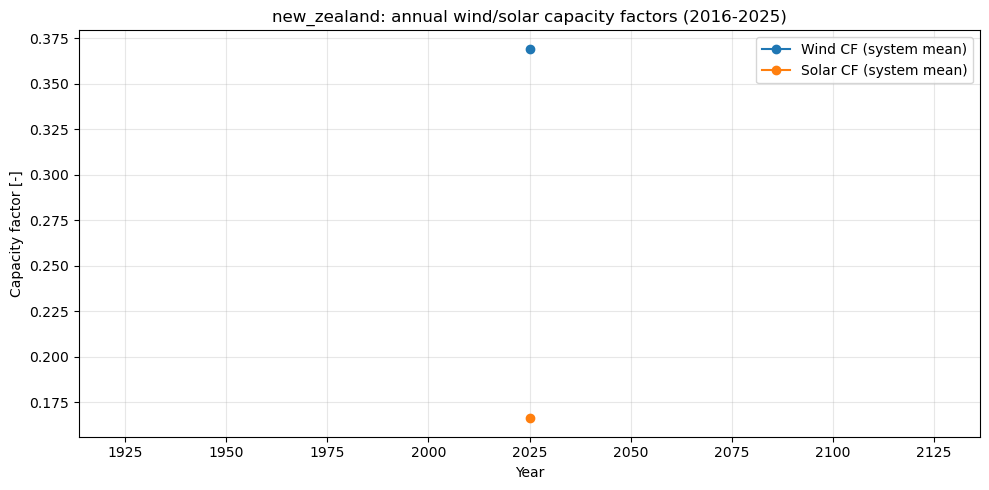

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(summary_df["year"], summary_df["wind_cf_mean_system"], marker="o", label="Wind CF (system mean)")
plt.plot(summary_df["year"], summary_df["solar_cf_mean_system"], marker="o", label="Solar CF (system mean)")
plt.title(f"{CASE_NAME}: annual wind/solar capacity factors (2016-2025)")
plt.xlabel("Year")
plt.ylabel("Capacity factor [-]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## NZ maps and CF diagnostics
This section adds:
- Wind and solar capacity factor maps over New Zealand (node-level means for the selected year).
- Capacity factor diagnostics in the same spirit as `case_analysis` (hourly traces and heatmaps).
- Wind profile diagnostics focused on minimums, maximums, and frequency of low/high wind conditions.

Mapping spatially-interpolated CF for year: 2025


,zone,lat,lon,wind_cf_mean,solar_cf_mean
0,auckland,-36.8485,174.7633,0.3700,0.1713
1,hamilton,-37.7870,175.2793,0.2656,0.1588
2,wellington,-41.2866,174.7756,0.5887,0.1715
3,christchurch,-43.5321,172.6362,0.2681,0.1714
4,dunedin,-45.8788,170.5028,0.3537,0.1572


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


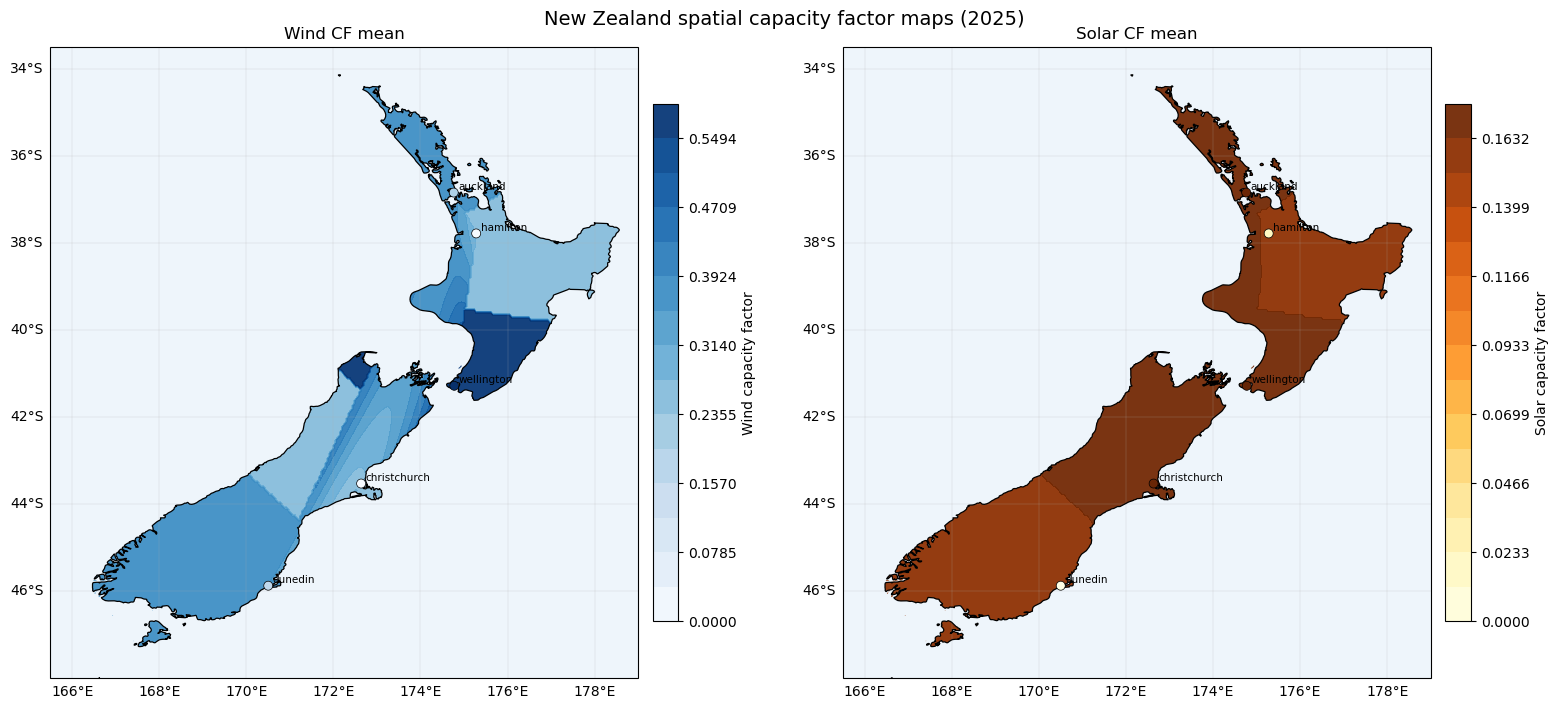

In [20]:
# NZ map: continuous wind/solar CF field over territory (selected year)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

analysis_year = int(YEARS[-1])
print(f"Mapping spatially-interpolated CF for year: {analysis_year}")

wind_mean_zone = wind_cf.mean(axis=0).rename("wind_cf_mean")
solar_mean_zone = solar_cf.mean(axis=0).rename("solar_cf_mean")

map_df = nodes_df[["zone", "lat", "lon"]].copy()
map_df = map_df.merge(wind_mean_zone, left_on="zone", right_index=True, how="left")
map_df = map_df.merge(solar_mean_zone, left_on="zone", right_index=True, how="left")

if map_df[["wind_cf_mean", "solar_cf_mean"]].isna().all().all():
    raise RuntimeError("Could not match node zones with computed CF columns.")

display(map_df[["zone", "lat", "lon", "wind_cf_mean", "solar_cf_mean"]].round(4))

import cartopy.crs as ccrs
import cartopy.feature as cfeature

lon_min, lon_max, lat_min, lat_max = 165.5, 179.0, -48.0, -33.5
n_lon, n_lat = 280, 240
lon_grid = np.linspace(lon_min, lon_max, n_lon)
lat_grid = np.linspace(lat_min, lat_max, n_lat)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

pts = np.column_stack([map_df["lon"].values, map_df["lat"].values])

def _idw_grid(values, power=2.0):
    values = np.asarray(values, dtype=float)
    diff_lon = LON[..., None] - pts[:, 0][None, None, :]
    diff_lat = LAT[..., None] - pts[:, 1][None, None, :]
    dist2 = diff_lon**2 + diff_lat**2
    dist2 = np.where(dist2 < 1e-12, 1e-12, dist2)
    w = 1.0 / np.power(dist2, power / 2.0)
    return np.sum(w * values[None, None, :], axis=2) / np.sum(w, axis=2)

def _interpolate_field(values):
    values = np.asarray(values, dtype=float)
    try:
        from scipy.interpolate import griddata
        field = griddata(pts, values, (LON, LAT), method="cubic")
        if np.isnan(field).any():
            nearest = griddata(pts, values, (LON, LAT), method="nearest")
            field = np.where(np.isnan(field), nearest, field)
    except Exception:
        field = _idw_grid(values, power=2.0)
    return np.clip(field, 0.0, 1.0)

wind_field = _interpolate_field(map_df["wind_cf_mean"].values)
solar_field = _interpolate_field(map_df["solar_cf_mean"].values)

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={"projection": proj})
fig.suptitle(f"New Zealand spatial capacity factor maps ({analysis_year})", fontsize=14)

layers = [
    (axes[0], wind_field, "Blues", "Wind CF mean", "Wind capacity factor"),
    (axes[1], solar_field, "YlOrBr", "Solar CF mean", "Solar capacity factor"),
]

for ax, field, cmap, title, cbar_label in layers:
    levels = np.linspace(0, max(0.05, float(np.nanmax(field))), 16)
    cf = ax.contourf(LON, LAT, field, levels=levels, cmap=cmap, transform=proj, alpha=0.95, zorder=1)

    # Paint ocean above interpolation so color remains focused on territory
    ax.add_feature(cfeature.OCEAN, facecolor="#eef5fb", zorder=2)
    ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="none", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.9, zorder=4)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title)

    sc = ax.scatter(
        map_df["lon"], map_df["lat"], c=map_df["wind_cf_mean"] if "Wind" in title else map_df["solar_cf_mean"],
        cmap=cmap, s=42, edgecolor="k", linewidth=0.5, transform=proj, zorder=5
    )
    for _, row in map_df.iterrows():
        ax.text(row["lon"] + 0.10, row["lat"] + 0.06, row["zone"], fontsize=7.5, transform=proj, zorder=6)

    cbar = fig.colorbar(cf, ax=ax, shrink=0.82, pad=0.02)
    cbar.set_label(cbar_label)

plt.tight_layout()
plt.show()

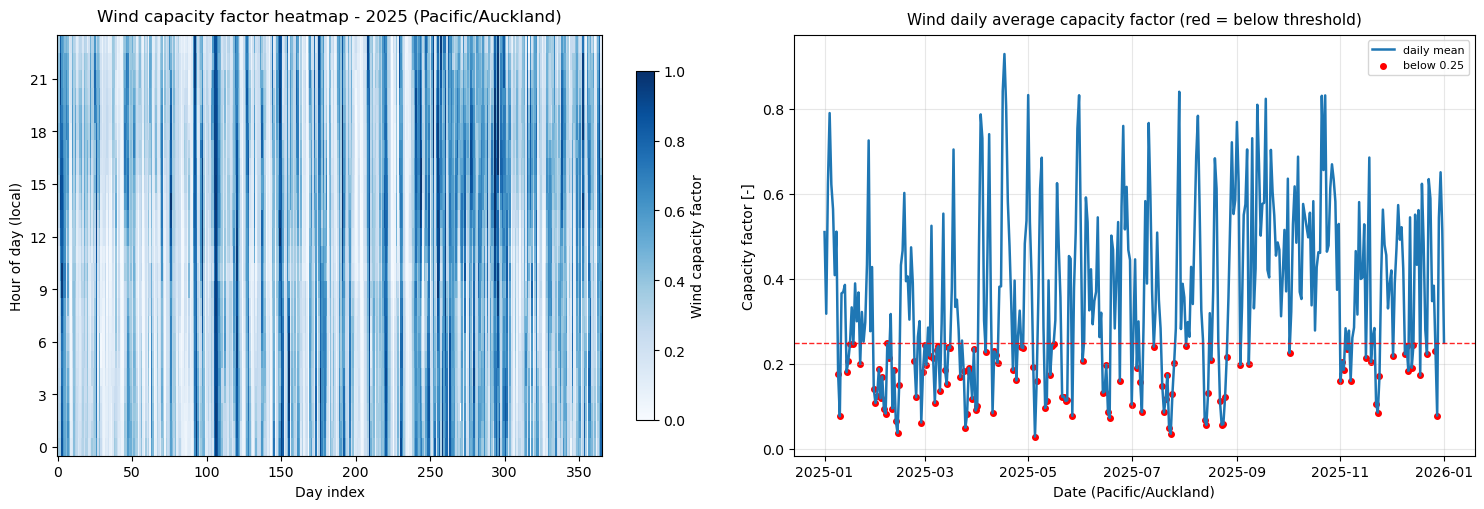

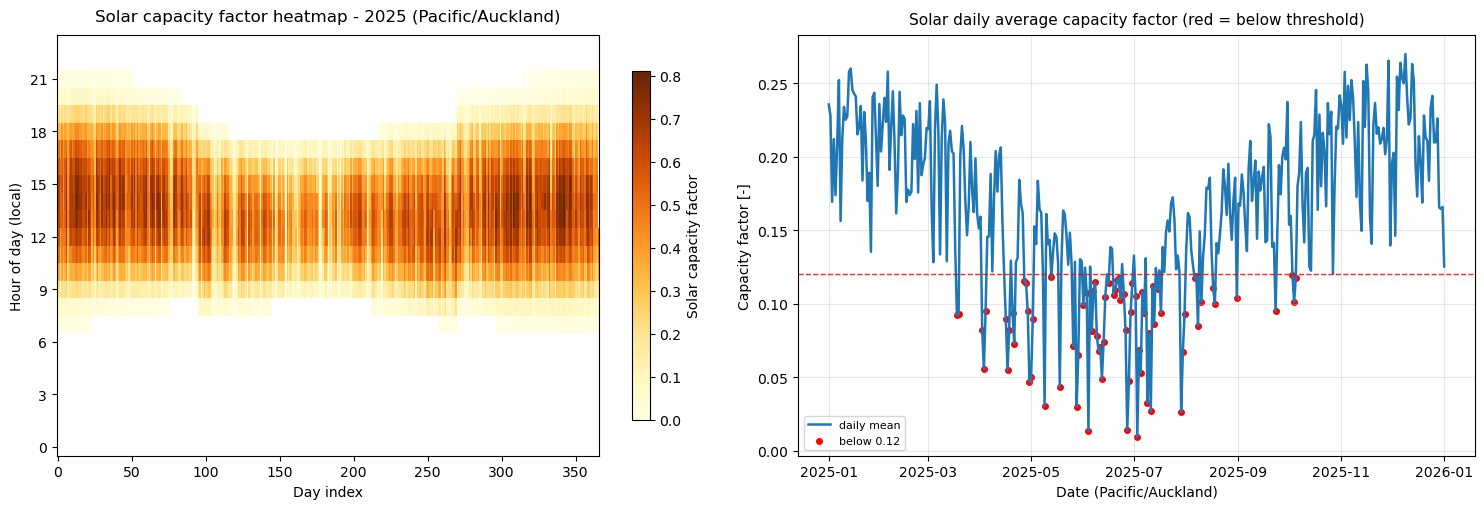

In [26]:
# Capacity factor diagnostics (case_analysis style: heatmap + daily average)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOT_TZ = "Pacific/Auckland"

def _prepare_cf_series(df: pd.DataFrame, tz_name: str = PLOT_TZ) -> pd.Series:
    if df is None or df.empty:
        raise ValueError("No capacity factor data available to plot.")

    s = df.mean(axis=1).copy()

    # Most reanalysis/cutout timestamps are UTC (often timezone-naive).
    # Convert to NZ local time so the hour-of-day axis is physically interpretable.
    idx = pd.to_datetime(s.index, utc=True)
    idx_local = idx.tz_convert(tz_name).tz_localize(None)
    s.index = idx_local

    return s

wind_series = _prepare_cf_series(wind_cf)
solar_series = _prepare_cf_series(solar_cf)

def _cf_heatmap_and_daily(series: pd.Series, title_prefix: str, cmap: str, threshold: float):
    heat_df = pd.DataFrame({
        "date": series.index.date,
        "hour": series.index.hour,
        "cf": series.values,
    })

    # Use pivot_table to handle duplicated local times during DST transitions.
    pivot = heat_df.pivot_table(index="date", columns="hour", values="cf", aggfunc="mean")
    pivot = pivot.reindex(columns=range(24))

    daily_avg = series.resample("D").mean()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

    # Heatmap panel (day horizontal, hour vertical)
    heat_vals = pivot.values.T  # rows=hour, cols=day

    # Keep exact-zero solar CF as blank in the heatmap.
    if title_prefix.lower() == "solar":
        heat_vals = np.where(heat_vals <= 0.0, np.nan, heat_vals)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="white")

    finite_max = np.nanmax(heat_vals) if np.isfinite(heat_vals).any() else 0.05
    im = axes[0].imshow(
        heat_vals,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
        cmap=cmap_obj,
        vmin=0.0,
        vmax=max(0.05, float(finite_max)),
    )
    axes[0].set_title(f"{title_prefix} capacity factor heatmap - {analysis_year} ({PLOT_TZ})", fontsize=12, pad=10)
    axes[0].set_xlabel("Day index")
    axes[0].set_ylabel("Hour of day (local)")
    axes[0].set_yticks(range(0, 24, 3))
    cbar = fig.colorbar(im, ax=axes[0], shrink=0.83)
    cbar.set_label(f"{title_prefix} capacity factor", fontsize=10)

    # Daily average panel
    axes[1].plot(daily_avg.index, daily_avg.values, color="#1f77b4", linewidth=1.8, label="daily mean")
    low_mask = daily_avg < threshold
    axes[1].scatter(
        daily_avg.index[low_mask], daily_avg.values[low_mask],
        color="red", s=16, label=f"below {threshold:.2f}"
    )
    axes[1].axhline(threshold, color="red", linestyle="--", linewidth=1, alpha=0.85)
    axes[1].set_title(f"{title_prefix} daily average capacity factor (red = below threshold)", fontsize=11, pad=8)
    axes[1].set_ylabel("Capacity factor [-]")
    axes[1].set_xlabel(f"Date ({PLOT_TZ})")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

_cf_heatmap_and_daily(wind_series, "Wind", cmap="Blues", threshold=0.25)
_cf_heatmap_and_daily(solar_series, "Solar", cmap="YlOrBr", threshold=0.12)

Wind CF summary statistics:


,value
wind_min,0.0000
wind_p05,0.0000
wind_mean,0.3692
wind_p95,1.0000
wind_max,1.0000
hours_cf_lt_0.10_pct,36.4269
hours_cf_lt_0.20_pct,48.7237
hours_cf_gt_0.50_pct,32.6826


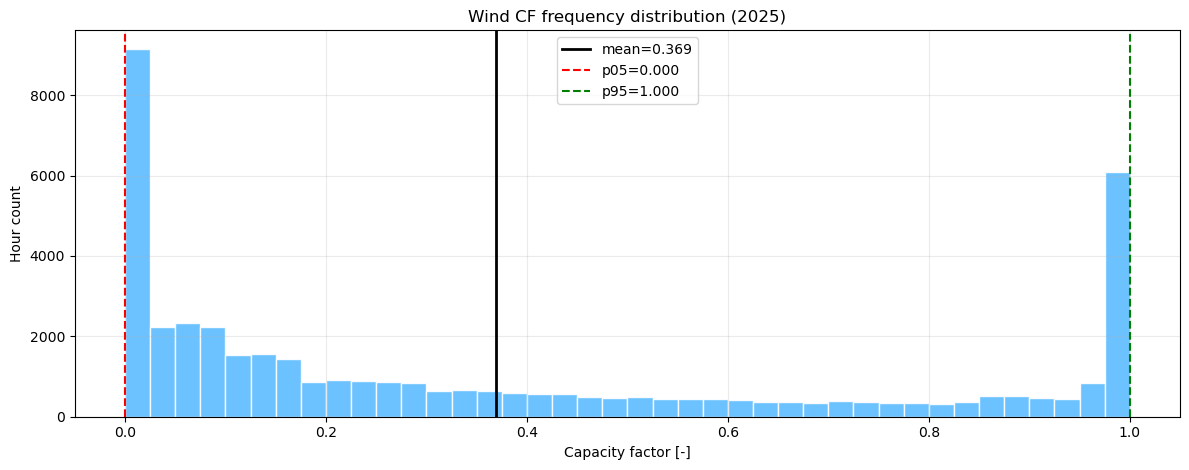

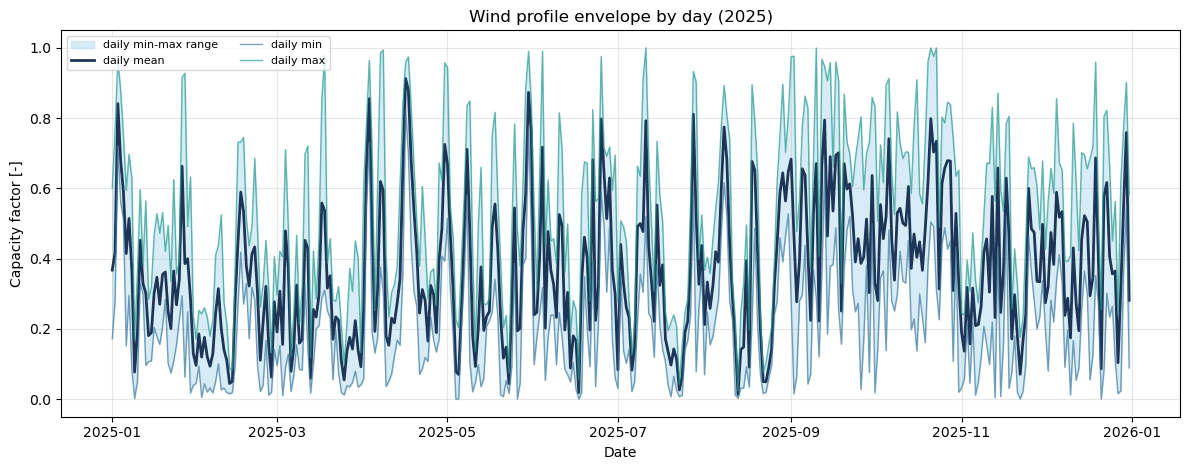

In [19]:
# Wind profile diagnostics: minimums, maximums, and frequency
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

wind_system = wind_cf.mean(axis=1).copy()
wind_system.index = pd.to_datetime(wind_system.index)

all_wind_vals = wind_cf.values.flatten()
all_wind_vals = all_wind_vals[np.isfinite(all_wind_vals)]

summary = pd.Series({
    "wind_min": float(np.min(all_wind_vals)),
    "wind_p05": float(np.percentile(all_wind_vals, 5)),
    "wind_mean": float(np.mean(all_wind_vals)),
    "wind_p95": float(np.percentile(all_wind_vals, 95)),
    "wind_max": float(np.max(all_wind_vals)),
    "hours_cf_lt_0.10_pct": float((all_wind_vals < 0.10).mean() * 100),
    "hours_cf_lt_0.20_pct": float((all_wind_vals < 0.20).mean() * 100),
    "hours_cf_gt_0.50_pct": float((all_wind_vals > 0.50).mean() * 100),
})

print("Wind CF summary statistics:")
display(summary.to_frame("value").round(4))

# Graph 1: Histogram + key statistics
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.hist(all_wind_vals, bins=40, color="#5bbcff", edgecolor="white", alpha=0.9)
ax.axvline(summary["wind_mean"], color="black", linewidth=2, label=f"mean={summary['wind_mean']:.3f}")
ax.axvline(summary["wind_p05"], color="red", linestyle="--", linewidth=1.5, label=f"p05={summary['wind_p05']:.3f}")
ax.axvline(summary["wind_p95"], color="green", linestyle="--", linewidth=1.5, label=f"p95={summary['wind_p95']:.3f}")
ax.set_title(f"Wind CF frequency distribution ({analysis_year})")
ax.set_xlabel("Capacity factor [-]")
ax.set_ylabel("Hour count")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Graph 2: Daily min/mean/max profile (envelope)
daily_min = wind_system.resample("D").min()
daily_mean = wind_system.resample("D").mean()
daily_max = wind_system.resample("D").max()

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.fill_between(daily_mean.index, daily_min.values, daily_max.values, color="#8ecae6", alpha=0.35, label="daily min-max range")
ax.plot(daily_mean.index, daily_mean.values, color="#1d3557", linewidth=2, label="daily mean")
ax.plot(daily_min.index, daily_min.values, color="#457b9d", linewidth=1, alpha=0.7, label="daily min")
ax.plot(daily_max.index, daily_max.values, color="#2a9d8f", linewidth=1, alpha=0.7, label="daily max")
ax.set_title(f"Wind profile envelope by day ({analysis_year})")
ax.set_xlabel("Date")
ax.set_ylabel("Capacity factor [-]")
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Wind diagnostics by zone (daily average + low-wind streaks)
This section reproduces, per zone, the two diagnostics requested:
- Daily average wind capacity factor with low-wind days highlighted.
- Longest consecutive low-wind days per month.

This is separate from the national aggregate shown above.

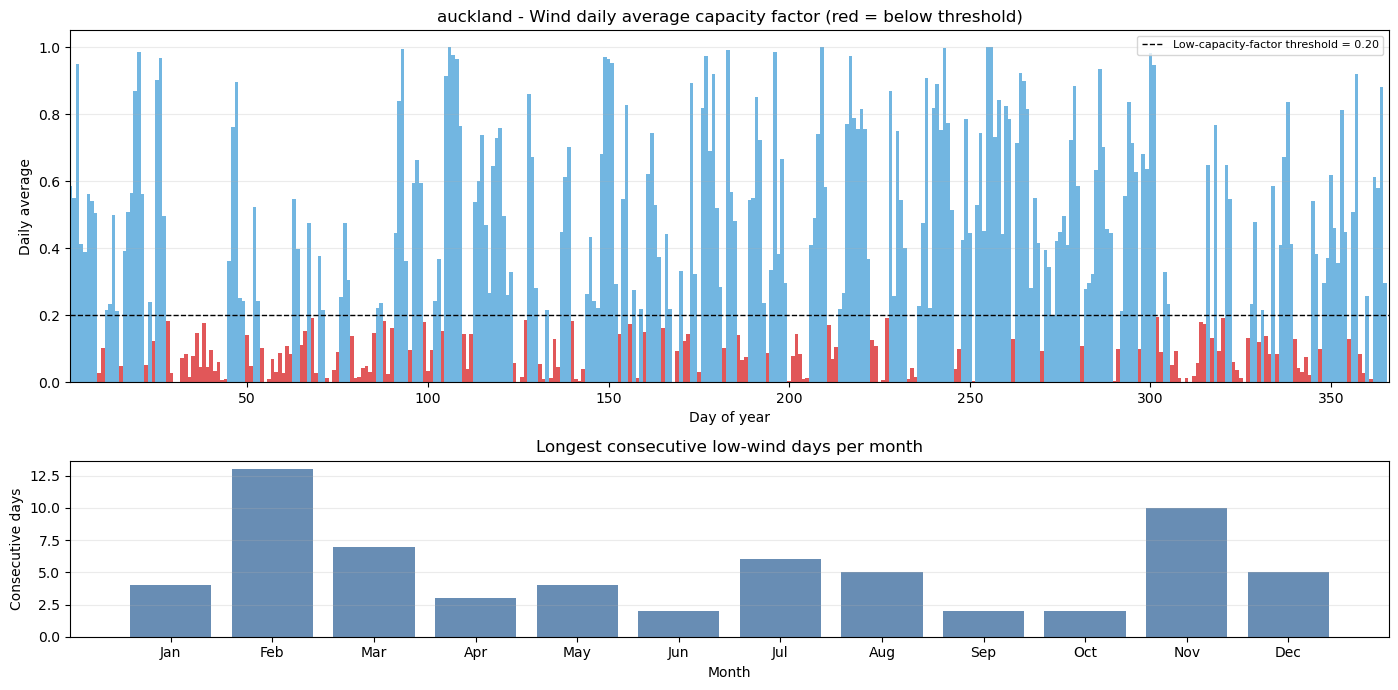

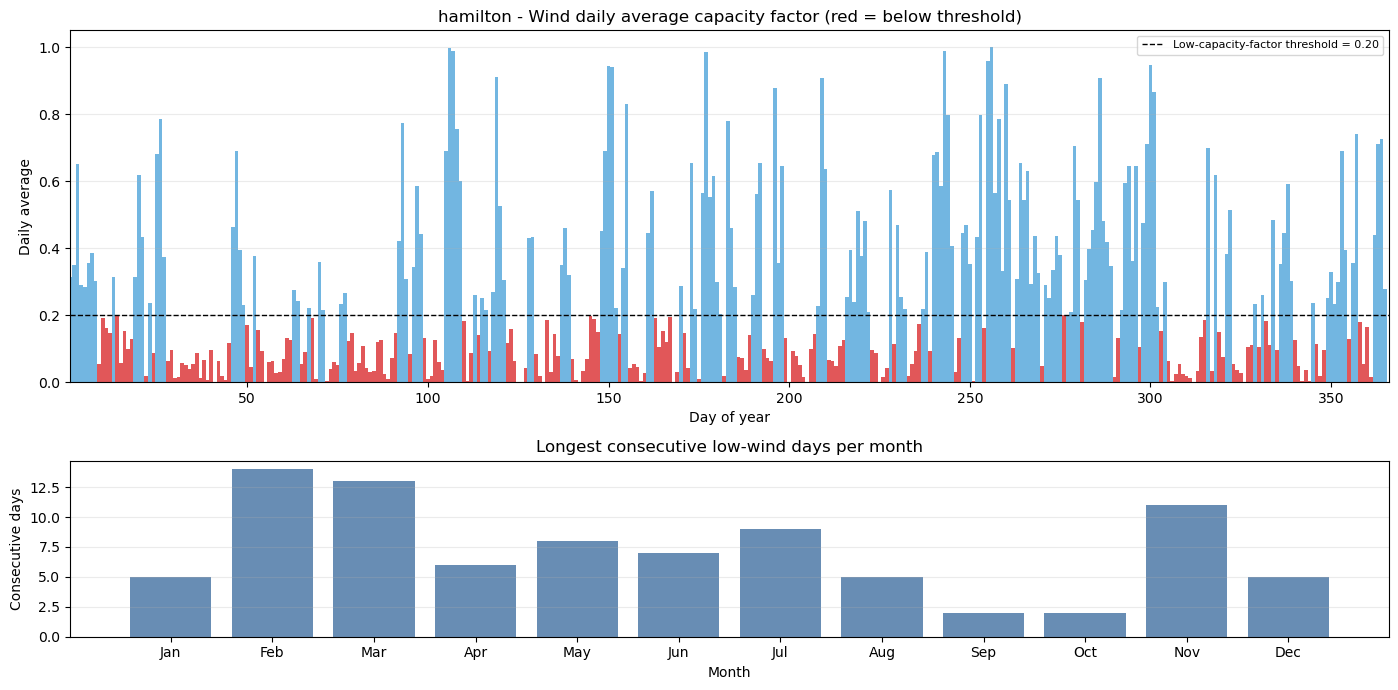

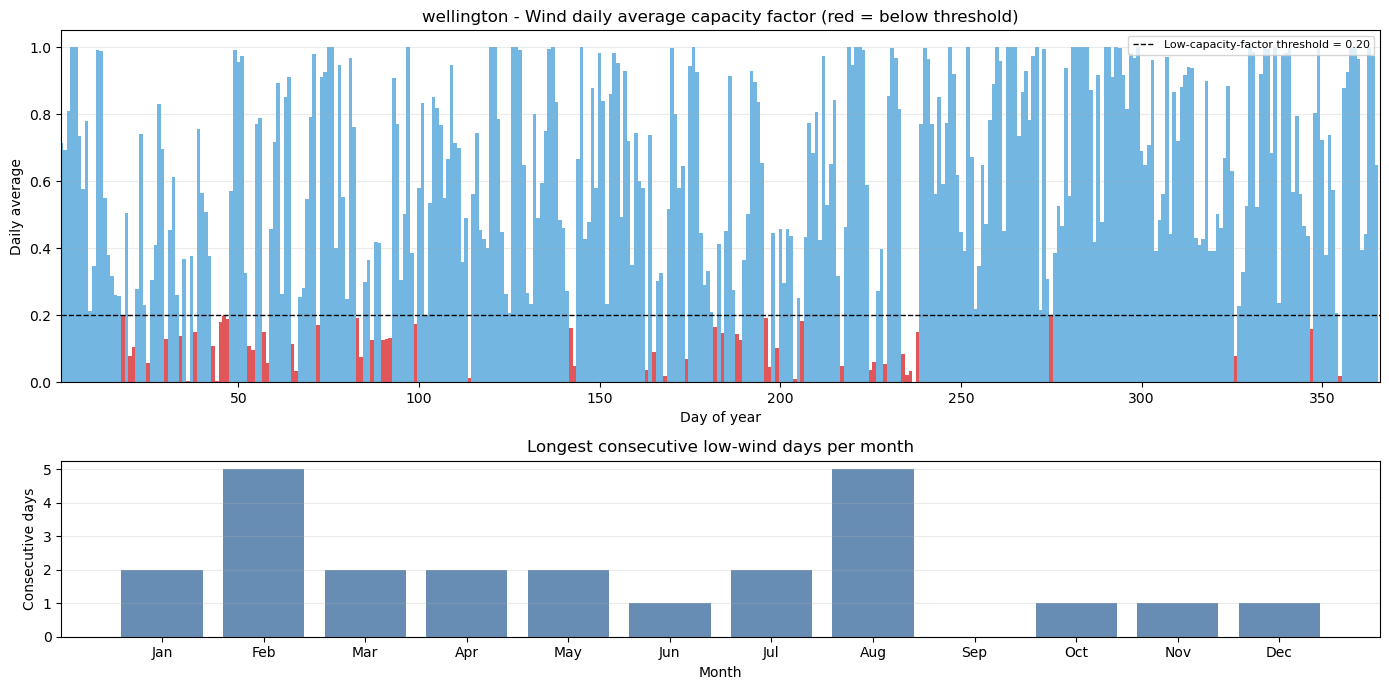

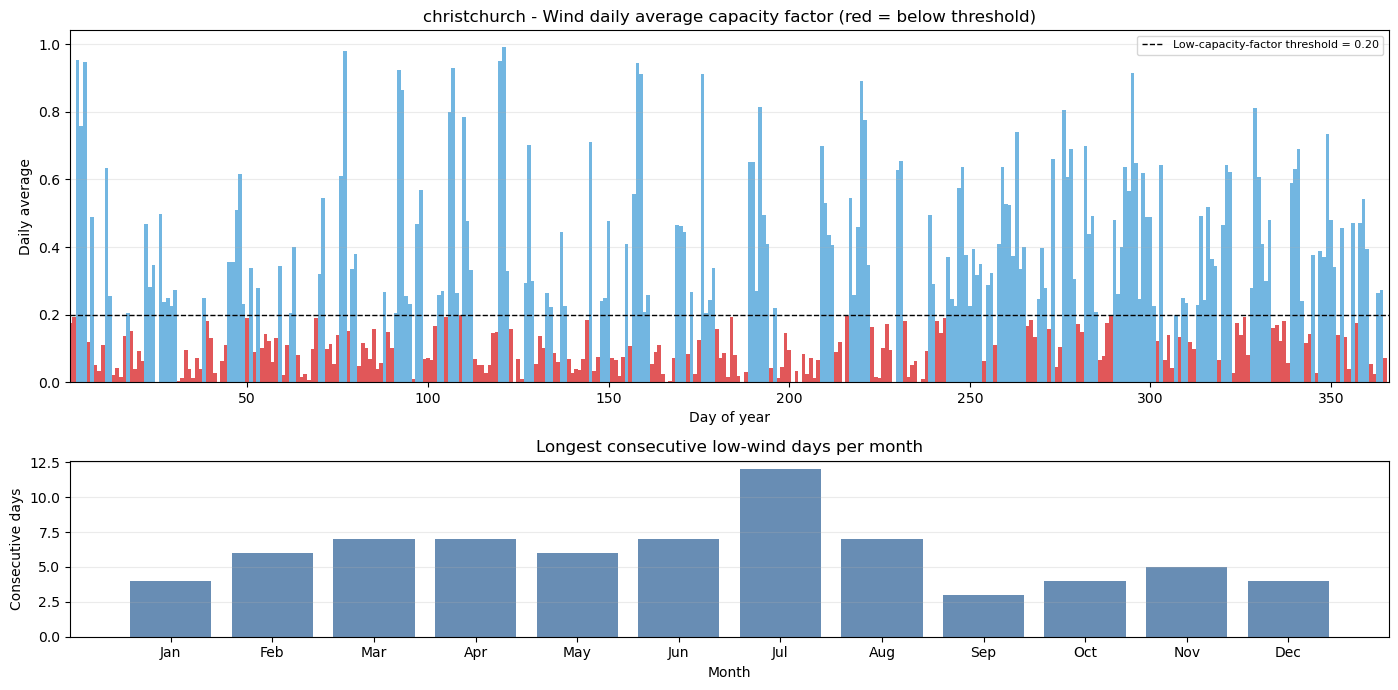

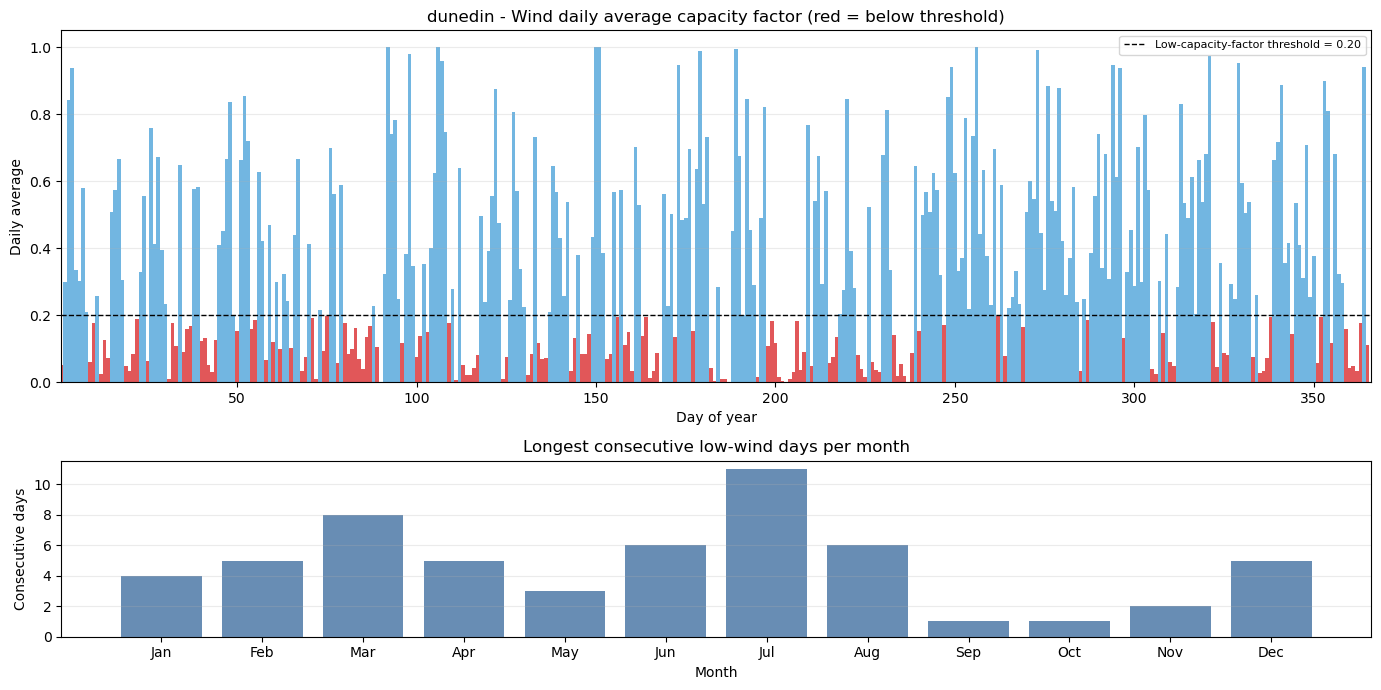

Summary table: longest consecutive low-wind days per month (by zone)


,zone,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,auckland,4,13,7,3,4,2,6,5,2,2,10,5
1,hamilton,5,14,13,6,8,7,9,5,2,2,11,5
2,wellington,2,5,2,2,2,1,2,5,0,1,1,1
3,christchurch,4,6,7,7,6,7,12,7,3,4,5,4
4,dunedin,4,5,8,5,3,6,11,6,1,1,2,5


In [22]:
# Per-zone wind diagnostics: daily average + longest consecutive low-wind days
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LOW_WIND_THRESHOLD = 0.20
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

daily_wind_zone = wind_cf.resample("D").mean()
daily_wind_zone.index = pd.to_datetime(daily_wind_zone.index)

def _longest_true_run(mask_array: np.ndarray) -> int:
    max_run = 0
    run = 0
    for v in mask_array.astype(bool):
        if v:
            run += 1
            if run > max_run:
                max_run = run
        else:
            run = 0
    return int(max_run)

records = []

for zone in daily_wind_zone.columns:
    zone_daily = daily_wind_zone[zone].dropna()
    if zone_daily.empty:
        continue

    low_mask = zone_daily < LOW_WIND_THRESHOLD
    day_of_year = zone_daily.index.dayofyear

    monthly_longest = []
    for m in range(1, 13):
        m_vals = zone_daily[zone_daily.index.month == m]
        if m_vals.empty:
            monthly_longest.append(0)
        else:
            m_low = (m_vals < LOW_WIND_THRESHOLD).to_numpy()
            monthly_longest.append(_longest_true_run(m_low))

    records.append({"zone": zone, **{month_labels[i]: monthly_longest[i] for i in range(12)}})

    # Plot pair per zone (same logic as case_analysis-style request)
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2.0, 1.0]})

    bar_colors = np.where(low_mask.values, "#e15759", "#72b6e1")
    axes[0].bar(day_of_year, zone_daily.values, color=bar_colors, width=1.0, edgecolor="none")
    axes[0].axhline(
        LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1.0,
        label=f"Low-capacity-factor threshold = {LOW_WIND_THRESHOLD:.2f}"
    )
    axes[0].set_title(f"{zone} - Wind daily average capacity factor (red = below threshold)")
    axes[0].set_ylabel("Daily average")
    axes[0].set_xlabel("Day of year")
    axes[0].set_xlim(1, 366)
    axes[0].grid(True, alpha=0.25, axis="y")
    axes[0].legend(loc="upper right", fontsize=8)

    axes[1].bar(month_labels, monthly_longest, color="#4e79a7", alpha=0.85)
    axes[1].set_title("Longest consecutive low-wind days per month")
    axes[1].set_ylabel("Consecutive days")
    axes[1].set_xlabel("Month")
    axes[1].grid(True, alpha=0.25, axis="y")

    plt.tight_layout()
    plt.show()

zone_low_wind_df = pd.DataFrame(records)
print("Summary table: longest consecutive low-wind days per month (by zone)")
display(zone_low_wind_df)

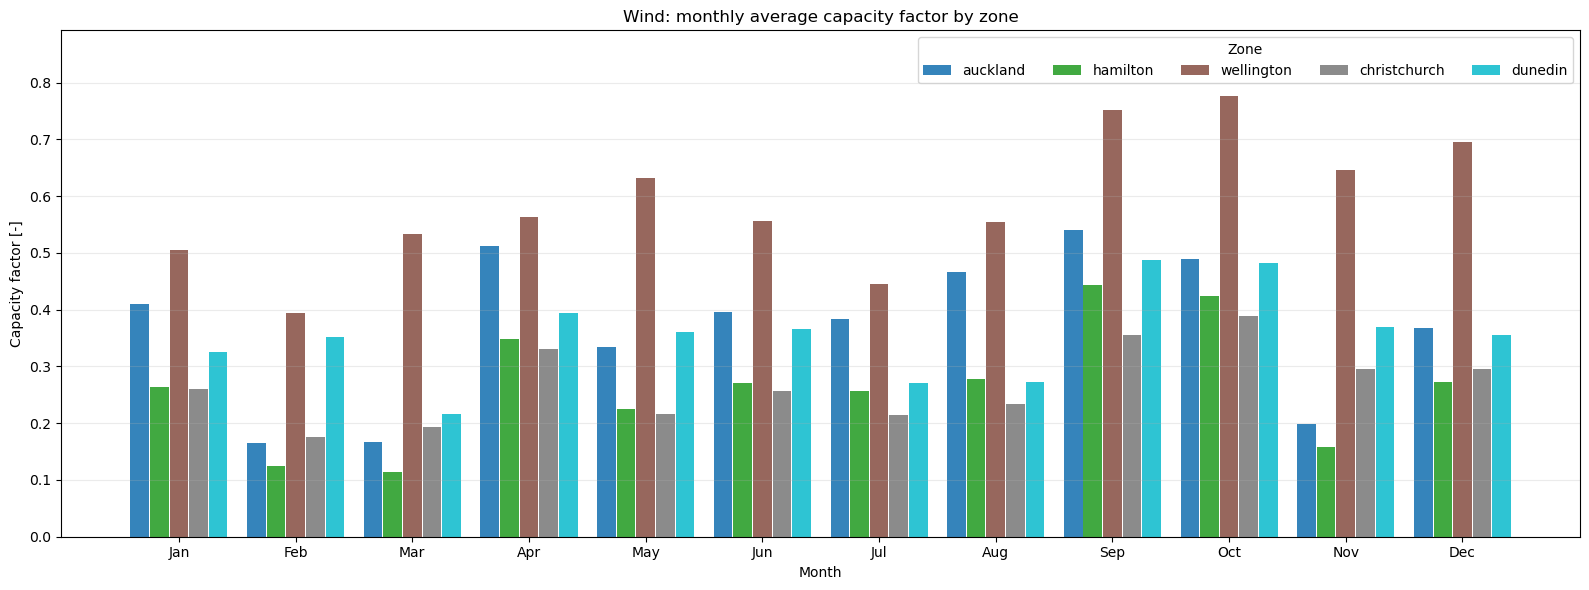

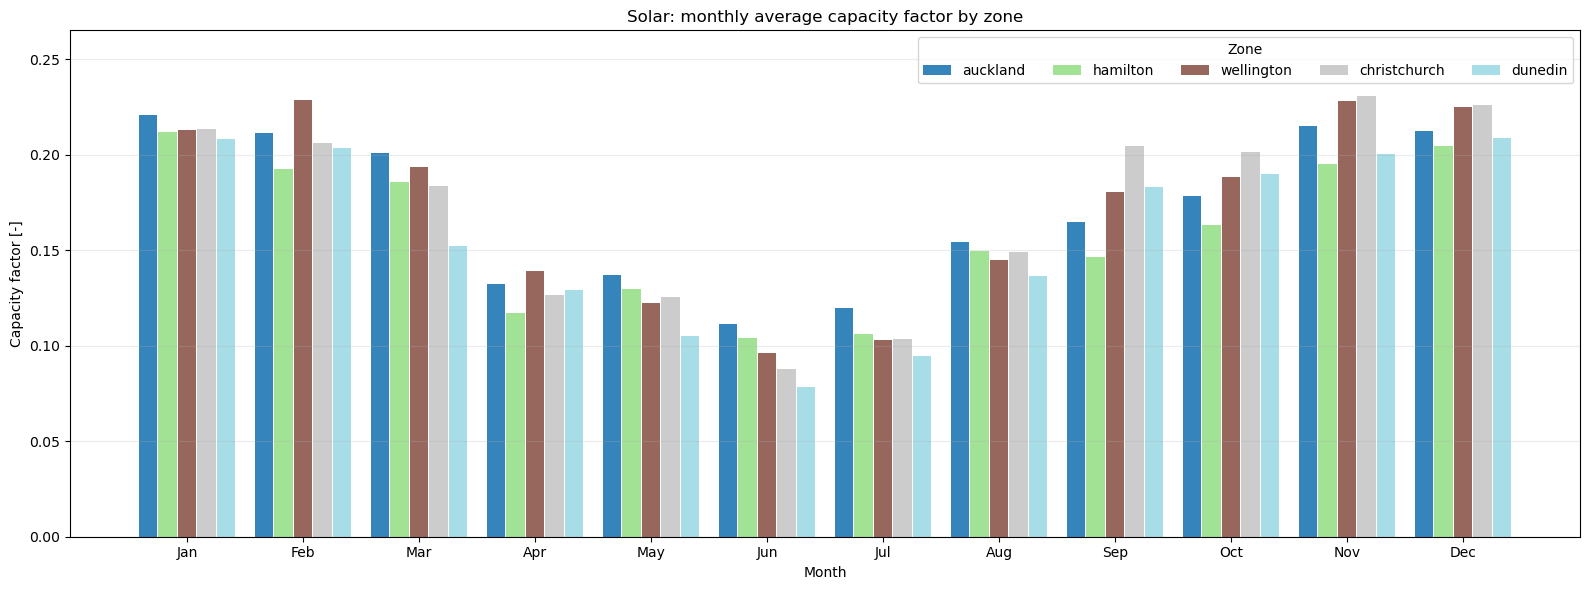

In [28]:
# Monthly average capacity factor by zone (single chart with color-coded zones)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def _plot_monthly_zone_grouped_bars(cf_df: pd.DataFrame, tech_name: str, cmap_name: str):
    if cf_df is None or cf_df.empty:
        raise ValueError(f"No {tech_name} CF data available.")

    # Monthly mean by zone; if multiple years exist, average same calendar month across years.
    monthly_mean = cf_df.resample("MS").mean()
    monthly_clim = monthly_mean.groupby(monthly_mean.index.month).mean()
    monthly_clim = monthly_clim.reindex(range(1, 13))

    zones = list(cf_df.columns)
    n_zones = len(zones)
    if n_zones == 0:
        raise ValueError(f"No zones found in {tech_name} data.")

    x = np.arange(12)
    total_width = 0.84
    bar_width = total_width / n_zones
    offsets = (np.arange(n_zones) - (n_zones - 1) / 2.0) * bar_width

    cmap = plt.get_cmap(cmap_name, n_zones)
    colors = [cmap(i) for i in range(n_zones)]

    fig, ax = plt.subplots(figsize=(16, 6))

    for i, zone in enumerate(zones):
        vals = monthly_clim[zone].values
        ax.bar(
            x + offsets[i],
            vals,
            width=bar_width * 0.95,
            color=colors[i],
            alpha=0.9,
            label=str(zone),
        )

    y_max = float(np.nanmax(monthly_clim.values)) if np.isfinite(monthly_clim.values).any() else 0.1
    ax.set_ylim(0, max(0.1, y_max * 1.15))
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")
    ax.set_ylabel("Capacity factor [-]")
    ax.set_title(f"{tech_name}: monthly average capacity factor by zone")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(title="Zone", ncol=min(5, n_zones), frameon=True)

    plt.tight_layout()
    plt.show()

_plot_monthly_zone_grouped_bars(wind_cf, "Wind", cmap_name="tab10")
_plot_monthly_zone_grouped_bars(solar_cf, "Solar", cmap_name="tab20")